# ISOM5240 Model Comparison — Pipeline 3: Image Captioning

**⚠️ Before running:** Set runtime to GPU (Runtime → Change runtime type → T4 GPU) for faster inference. CPU also works but slower.

**Colab Secrets required (🔑 left sidebar):** `KAGGLE_USERNAME`, `KAGGLE_KEY`

**Pipeline 3:** Product image → Auto-generated text description  

This notebook compares 3 captioning models (BLIP-base, BLIP-large, GIT-base) on inference speed and output quality, then selects the best for deployment.

**Test images from:**
- Grocery Store Dataset (GitHub) → fruits, vegetables, dairy
- Kaggle Household Products → household items

## Step 1: Install dependencies

In [2]:
!pip install transformers pillow -q

In [3]:
from transformers import pipeline as hf_pipeline
import pandas as pd

## Step 2: GPU check

In [4]:
import torch
import os
import time
import numpy as np

if torch.cuda.is_available():
    DEVICE = 0
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = -1
    print("No GPU, using CPU (fine — no training needed)")

Using GPU: Tesla T4


## Step 3: Setup Kaggle credentials

In [5]:
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get('KAGGLE_USERNAME')
os.environ["KAGGLE_KEY"] = userdata.get('KAGGLE_KEY')
print("Kaggle credentials set")

Kaggle credentials set


## Step 4: Download both datasets

1. Grocery Store Dataset (GitHub) → fruits, vegetables, dairy
2. Kaggle Household Products → tissue, cleaning supplies, etc.

In [6]:
# Dataset 1: Grocery Store Dataset
!git clone https://github.com/marcusklasson/GroceryStoreDataset.git
print("Grocery Store Dataset downloaded")

# Dataset 2: Household Products
!kaggle datasets download -d taru149/householdproducts
!unzip -q householdproducts.zip -d household/
print("Household Products downloaded")

# Check structure
print("\nGrocery Store test folders:")
grocery_test = "GroceryStoreDataset/dataset/test"
if os.path.exists(grocery_test):
    print(os.listdir(grocery_test))

print("\nHousehold folders:")
!find household/ -type d | head -20

Cloning into 'GroceryStoreDataset'...
remote: Enumerating objects: 6559, done.
remote: Counting objects: 100% (264/264), done.
remote: Compressing objects: 100% (229/229), done.
remote: Total 6559 (delta 45), reused 35 (delta 35), pack-reused 6295 (from 2)
Receiving objects: 100% (6559/6559), 116.26 MiB | 26.73 MiB/s, done.
Resolving deltas: 100% (275/275), done.
Updating files: 100% (5717/5717), done.
Grocery Store Dataset downloaded
Dataset URL: https://www.kaggle.com/datasets/taru149/householdproducts
License(s): unknown
100% 33.4M/33.4M [00:00<00:00, 45.5MB/s]

Household Products downloaded

Grocery Store test folders:
['Packages', 'Vegetables', 'Fruit']

Household folders:
household/
household/Household-Products
household/Household-Products/validation
household/Household-Products/validation/annotations
household/Household-Products/validation/images
household/Household-Products/train
household/Household-Products/train/annotations
household/Household-Products/train/images


## Step 5: Build combined 3-class test set

- short_shelf (0): fruits, vegetables from Grocery Store Dataset
- medium_shelf (1): dairy, juice from Grocery Store Dataset
- non_perishable (2): household products from Kaggle

In [7]:
from PIL import Image
import glob

DATA_ROOT = "GroceryStoreDataset/dataset"

# Shelf-life keywords
SHORT_KEYWORDS = [
    "apple", "avocado", "banana", "kiwi", "lemon", "lime", "mango",
    "melon", "nectarine", "orange", "papaya", "passion", "peach",
    "pear", "pineapple", "plum", "pomegranate", "grapefruit",
    "satsuma", "watermelon", "asparagus", "aubergine", "cabbage",
    "carrot", "cucumber", "garlic", "ginger", "leek", "mushroom",
    "onion", "pepper", "potato", "red-beet", "tomato", "zucchini"
]

MEDIUM_KEYWORDS = [
    "juice", "milk", "oat", "sour-cream", "sour-milk",
    "soy", "yoghurt", "cream"
]

LABEL_NAMES_P1 = ["short_shelf", "medium_shelf", "non_perishable"]

# Collect from Grocery Store Dataset (recursive)
test_images = []
test_labels = []

test_dir = os.path.join(DATA_ROOT, "test")
for root, dirs, files in os.walk(test_dir):
    folder_name = os.path.basename(root).lower()

    if any(kw in folder_name for kw in SHORT_KEYWORDS):
        label = 0
    elif any(kw in folder_name for kw in MEDIUM_KEYWORDS):
        label = 1
    else:
        continue

    for f in files:
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")):
            test_images.append(os.path.join(root, f))
            test_labels.append(label)

# Collect from Household Products (all = non_perishable)
household_paths = (glob.glob("household/**/*.jpg", recursive=True) +
                   glob.glob("household/**/*.png", recursive=True) +
                   glob.glob("household/**/*.jpeg", recursive=True))

for path in household_paths:
    test_images.append(path)
    test_labels.append(2)

test_labels = np.array(test_labels)
print(f"Combined test set: {len(test_images)} images")
print(f"  short_shelf (0):    {(test_labels==0).sum()}")
print(f"  medium_shelf (1):   {(test_labels==1).sum()}")
print(f"  non_perishable (2): {(test_labels==2).sum()}")

Combined test set: 2390 images
  short_shelf (0):    1456
  medium_shelf (1):   586
  non_perishable (2): 348


---
# Pipeline 3: Image Captioning

## Step 9: Compare 3 captioning models

No accuracy metric for captioning — compare inference speed + output quality.

In [8]:
# Select diverse samples: 2 short, 2 medium, 2 non_perishable
diverse_indices = []
for label_id in [0, 1, 2]:
    indices = [i for i, l in enumerate(test_labels) if l == label_id]
    diverse_indices.extend(indices[:2])

diverse_images = [test_images[i] for i in diverse_indices]
print(f"Selected {len(diverse_images)} diverse images: 2 short + 2 medium + 2 non_perishable")

Selected 6 diverse images: 2 short + 2 medium + 2 non_perishable


In [9]:
PIPELINE3_MODELS = {
    "BLIP-base": "Salesforce/blip-image-captioning-base",
    "BLIP-large": "Salesforce/blip-image-captioning-large",
    "GIT-base": "microsoft/git-base-coco",
}

def evaluate_p3(model_key, model_path, image_paths, num_samples=20):
    print(f"\nEvaluating: {model_key}")

    pipe = hf_pipeline("image-text-to-text", model=model_path, device=DEVICE)
    total_params = sum(p.numel() for p in pipe.model.parameters())

    inference_times = []
    sample_outputs = []

    n = min(num_samples, len(image_paths))
    for i in range(n):
        img = Image.open(image_paths[i]).convert("RGB")
        t0 = time.time()
        result = pipe(img, text="a photo of", max_new_tokens=50)
        inference_times.append(time.time() - t0)

        # Save output for display
        if isinstance(result, list) and len(result) > 0:
            item = result[0]
            if isinstance(item, dict):
                text = item.get("generated_text", str(item))
            elif isinstance(item, list) and len(item) > 0:
                text = item[0].get("generated_text", str(item[0]))
            else:
                text = str(item)
        else:
            text = str(result)
        sample_outputs.append(text)

    avg_ms = np.mean(inference_times) * 1000

    print(f"  Speed: {avg_ms:.1f}ms | Params: {total_params/1e6:.1f}M")
    print(f"  Sample outputs:")
    for j, s in enumerate(sample_outputs):
        print(f"    [{j+1}] {s}")

    return {
        "Model": model_key,
        "Parameters (M)": f"{total_params/1e6:.1f}M",
        "Avg Inference (ms)": round(avg_ms, 1),
        "Samples Tested": n,
        "Sample Output": sample_outputs[0] if sample_outputs else "",
    }

In [10]:
# Run Pipeline 3 comparison
p3_results = []

for key, path in PIPELINE3_MODELS.items():
    r = evaluate_p3(key, path, diverse_images)
    p3_results.append(r)

df_p3 = pd.DataFrame(p3_results)
print("\n" + "="*60)
print("PIPELINE 3 RESULTS: Image Captioning")
print("="*60)
print(df_p3[["Model", "Parameters (M)", "Avg Inference (ms)"]].to_string(index=False))


Evaluating: BLIP-base


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `m

  Speed: 304.4ms | Params: 176.6M
  Sample outputs:
    [1] a photo of - breakfast in a supermarket
    [2] a photo of - - a person holding a bottle of juice in hand and a bottle of juice
    [3] a photo of a person holding a carton of milk in a supermarket
    [4] a photo of milk in a supermarket.
    [5] a photo of product line
    [6] a photo of product

PIPELINE 3 RESULTS: Image Captioning
     Model Parameters (M)  Avg Inference (ms)
 BLIP-base         247.4M               694.4
BLIP-large         469.7M               322.7
  GIT-base         176.6M               304.4


## Step 10: Select best model for Pipeline 3

In [11]:
best_p3 = min(p3_results, key=lambda x: x["Avg Inference (ms)"])
print(f"Fastest for Pipeline 3: {best_p3['Model']} ({best_p3['Avg Inference (ms)']}ms)")
print(f"\nAlso review sample outputs above — pick the one with best quality if speeds are similar.")
print(f"→ Use selected model in app.py: load_image_captioner()")

Fastest for Pipeline 3: GIT-base (304.4ms)

Also review sample outputs above — pick the one with best quality if speeds are similar.
→ Use selected model in app.py: load_image_captioner()


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/305 [00:00<?, ?it/s]

GitForCausalLM LOAD REPORT from: microsoft/git-base-coco
Key                                                    | Status     |  | 
-------------------------------------------------------+------------+--+-
git.embeddings.position_ids                            | UNEXPECTED |  | 
git.image_encoder.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=50) an

Image,BLIP-base,BLIP-large,GIT-base
God-Morgon-Orange-Red-Grapefruit-Juice_011.jpg(short),a photo of a person holding a box of orange juice,a photo of a person holding a carton of orange juice,a photo of - breakfast in a supermarket
God-Morgon-Orange-Red-Grapefruit-Juice_018.jpg(short),a photo of a person holding a box of food,a photo of a person holding a carton of orange juice,a photo of - - a person holding a bottle of juice in hand and a bottle of juice
Arla-Lactose-Medium-Fat-Milk_016.jpg(medium),a photo of someone holding a carton of milk,a photo of a person holding a carton of milk in front of a refrigerator,a photo of a person holding a carton of milk in a supermarket
Arla-Lactose-Medium-Fat-Milk_017.jpg(medium),a photo of a hand holding a bottle of milk,a photo of a person holding a carton of milk in front of a shelf,a photo of milk in a supermarket.
himalaya-shampoo(3).jpg(non_perishable),a photo of a bottle of herbal hair care products,a photo of two bottles of shampooe sitting on a table,a photo of product line
dettol(8).jpg(non_perishable),a photo of det det det det det det det det det det det det det det det det det det,a photo of a bottle of dettol hand sanitizer,a photo of product

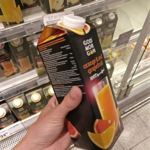
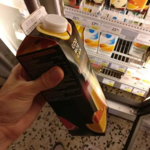
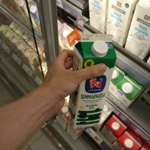
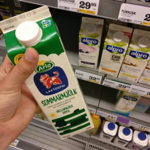
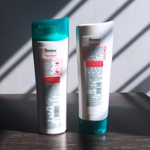
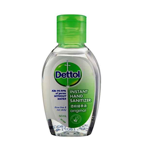

In [12]:
from IPython.display import display, HTML
import base64
from io import BytesIO

# Load all 3 models
pipes = {
    "BLIP-base": hf_pipeline("image-text-to-text", model="Salesforce/blip-image-captioning-base", device=DEVICE),
    "BLIP-large": hf_pipeline("image-text-to-text", model="Salesforce/blip-image-captioning-large", device=DEVICE),
    "GIT-base": hf_pipeline("image-text-to-text", model="microsoft/git-base-coco", device=DEVICE),
}

html = "<h3>Image vs Caption Quality Review</h3>"
html += "<table border='1' style='border-collapse:collapse; font-size:13px'>"
html += "<tr><th style='padding:8px'>Image</th><th style='padding:8px'>BLIP-base</th><th style='padding:8px'>BLIP-large</th><th style='padding:8px'>GIT-base</th></tr>"

for i in range(len(diverse_images)):
    img = Image.open(diverse_images[i]).convert("RGB")

    # Convert image to base64 for inline display
    buf = BytesIO()
    img.resize((150, 150)).save(buf, format="PNG")
    img_b64 = base64.b64encode(buf.getvalue()).decode()

    captions = {}
    for name, pipe in pipes.items():
        result = pipe(img, text="a photo of", max_new_tokens=50)
        if isinstance(result, list) and len(result) > 0:
            item = result[0]
            if isinstance(item, dict):
                captions[name] = item.get("generated_text", str(item))
            elif isinstance(item, list):
                captions[name] = item[0].get("generated_text", str(item[0]))
        else:
            captions[name] = str(result)

    # Get category label for this image
    cat_label = ["short", "medium", "non_perishable"][test_labels[diverse_indices[i]]]
    fname = os.path.basename(diverse_images[i])

    html += f"<tr>"
    html += f"<td style='padding:8px'><img src='data:image/png;base64,{img_b64}' width='150'><br><small>{fname}<br>({cat_label})</small></td>"
    html += f"<td style='padding:8px'>{captions.get('BLIP-base','')}</td>"
    html += f"<td style='padding:8px'>{captions.get('BLIP-large','')}</td>"
    html += f"<td style='padding:8px'>{captions.get('GIT-base','')}</td>"
    html += f"</tr>"

html += "</table>"
display(HTML(html))

## Step 11: Export results to Excel

In [13]:
with pd.ExcelWriter("P3_Experiments.xlsx") as writer:
    df_p3[["Model", "Parameters (M)", "Avg Inference (ms)", "Sample Output"]].to_excel(
        writer, sheet_name="P3 Captioning", index=False
    )

print("Saved to P3_Experiments.xlsx")

from google.colab import files
files.download("P3_Experiments.xlsx")
print("Downloaded!")

Saved to P3_Experiments.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded!


---
## Summary

| Step | Content |
|------|---------|
| 1-3 | Setup: dependencies, GPU check, Kaggle credentials |
| 4-5 | Download Grocery Store Dataset + Household Products for test images |
| 6-8 | **Pipeline 3:** BLIP-base vs BLIP-large vs GIT-base → speed + quality → select best |
| 9 | Export Excel + auto-download |

**Dataset sources (for test images only):**
- Grocery Store Dataset: https://github.com/marcusklasson/GroceryStoreDataset
- Kaggle Household Products: https://www.kaggle.com/datasets/taru149/householdproducts